# Учебный хакатон: предсказание целевого действия

## План работы

1. **Подготовка данных**
   - Прочитать датасеты и изучить описание атрибутов.
   - Оценить полноту, чистоту и структуру данных.
   - Привести данные к удобному виду: типизация, обработка пропусков, удаление дубликатов и т.д.

2. **Разведочный анализ (EDA)**
   - Исследовать распределения ключевых признаков (histograms, boxplots).
   - Построить тепловую карту корреляций.
   - Добавить комментарии с интерпретацией: какие связи и аномалии заметны.

3. **Модель машинного обучения**
   - Построить модель, предсказывающую вероятность совершения целевого действия.
   - Ориентир по метрике качества: ROC-AUC ≈ 0.65.
   - Подходить к фиче-инжинирингу осмысленно:
     - создать новые признаки;
     - проверить линейные зависимости;
     - интерпретировать значимость признаков.

4. **Упаковка модели**
   - Сделать API или скрипт, который:
     - принимает данные по визиту (utm, geo, device и т.д.);
     - возвращает 0 или 1 (будет ли целевое действие).

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
SESSIONS_PATH = "data/ga_sessions.pkl"
HITS_PATH = "data/ga_hits.csv"

df_sessions = pd.read_pickle(SESSIONS_PATH)


chunks = []
for chunk in pd.read_csv(HITS_PATH, chunksize=100_000):
    chunks.append(chunk)

df_hits = pd.concat(chunks, ignore_index=True)

df_sessions.shape, df_hits.shape

((1860042, 18), (15726470, 11))

In [45]:
from phik import phik_matrix

## 1. Подготовка данных

Сначала изучим структуру датасетов, типы признаков и объем данных, чтобы понять, с чем предстоит работать.

In [4]:
df_hits.info()
print("\n")
df_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium            

In [5]:
df_hits.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [6]:
df_sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


### Анализ пропусков

Посчитаем долю пропусков по каждому признаку и оценим, какие колонки стоит удалить, а какие — аккуратно заполнить.

In [7]:
missing_hits = (df_hits.isna().mean() * 100).sort_values(ascending=False)
print(missing_hits)

event_value       100.000000
hit_time           58.247795
hit_referer        39.899634
event_label        23.909905
session_id          0.000000
hit_date            0.000000
hit_number          0.000000
hit_type            0.000000
hit_page_path       0.000000
event_category      0.000000
event_action        0.000000
dtype: float64


`event_value` полностью пустой, поэтому признак бесполезен и его можно удалить.  
`hit_time` имеет более 50% пропусков, потребуется отдельное решение по заполнению или аккуратному использованию.

In [139]:
missing_sessions = (df_sessions.isna().mean() * 100).sort_values(ascending=False)
print(missing_sessions)

device_model                99.121633
utm_keyword                 58.174009
device_os                   57.533002
device_brand                19.740307
utm_adcontent               18.043410
utm_campaign                11.806346
utm_source                   0.005215
geo_country                  0.000000
device_browser               0.000000
device_screen_resolution     0.000000
session_id                   0.000000
device_category              0.000000
client_id                    0.000000
utm_medium                   0.000000
visit_number                 0.000000
visit_time                   0.000000
visit_date                   0.000000
geo_city                     0.000000
dtype: float64


В сессиях почти полностью пустой `device_model`, его также имеет смысл удалить.  
Высокие доли пропусков у `utm_keyword`, `device_os`, `device_brand`, `utm_adcontent`, `utm_campaign` — эти признаки будем скорее заполнять маркером `(other)`, чтобы не терять строки.

In [8]:
duplets_hits = df_hits.duplicated().sum()
duplets_sessions = df_sessions.duplicated().sum()

print(f'Дубликаты в hits: {duplets_hits}')
print(f'Дубликаты в sessions: {duplets_sessions}')

Дубликаты в hits: 0
Дубликаты в sessions: 0


### Кардинальность признаков

Оценим количество уникальных значений по столбцам, чтобы понять, какие признаки высокоразмерные и могут потребовать аккуратного кодирования.

In [9]:
unique_hits = df_hits.nunique().sort_values(ascending=False)
unique_sessions = df_sessions.nunique().sort_values(ascending=False)

print(unique_hits)
print("\n")
print(unique_sessions)

session_id        1734610
hit_time           925887
hit_page_path      342715
event_label         39825
hit_referer         37873
hit_number            500
event_action          230
hit_date              226
event_category         52
hit_type                1
event_value             0
dtype: int64


session_id                  1860042
client_id                   1391719
visit_time                    85318
device_screen_resolution       5039
geo_city                       2548
utm_keyword                    1219
visit_number                    537
utm_campaign                    412
utm_source                      293
utm_adcontent                   286
visit_date                      226
device_brand                    206
geo_country                     166
device_model                    104
device_browser                   57
utm_medium                       56
device_os                        13
device_category                   3
dtype: int64


### Частотные таблицы категориальных признаков

Сформируем удобную функцию для вывода топ-N значений категориальных колонок, чтобы лучше понять распределение.

In [11]:
def freq_table(df, col):
    vc = df[col].value_counts(dropna=False)
    result = pd.DataFrame({
        'value': vc.index,
        'count': vc.values,
        'pct': (vc.values / len(df) * 100).round(2)
    })
    return result

sessions_cols = [
    'utm_source', 'utm_medium', 'utm_campaign',
    'device_category', 'device_os', 'device_browser',
    'device_brand', 'geo_country', 'geo_city',
    'visit_number'
]

hits_cols = [
    'event_category', 'event_action', 'event_label',
    'hit_type', 'hit_page_path'
]

print("SESSIONS\n")
for col in sessions_cols:
    print(f"\n{col} (топ 15)")
    print(freq_table(df_sessions, col).head(15).to_string(index=False))
    print("\n")

print("HITS")
for col in hits_cols:
    print(f"\n{col} (топ 15)")
    print(freq_table(df_hits, col).head(15).to_string(index=False))

SESSIONS


utm_source (топ 15)
               value  count   pct
ZpYIoDJMcFzVoPFsHGJL 578290 31.09
fDLlAcSmythWSCVMvqvL 300575 16.16
kjsLglQLzykiRbcDiGcD 266354 14.32
MvfHsxITijuriZxsqZqt 186199 10.01
BHcvLfOaCWvWTykYqHVe 116320  6.25
bByPQxmDaMXgpHeypKSM 102287  5.50
QxAxdyPLuQMEcrdZWdWb  51415  2.76
aXQzDWsJuGXeBXexNHjc  31152  1.67
jaSOmLICuBzCFqHfBdRg  29241  1.57
RmEBuqrriAfAVsLQQmhk  28055  1.51
vFcAhRxLfOWKhvxjELkx  24413  1.31
PlbkrSYoHuZBWfYjYnfw  20792  1.12
hTjLvqNxGggkGnxSCaTm  14598  0.78
gDBGzjFKYabGgSPZvrDH  13565  0.73
fgymSoTvjKPEgaIJqsiH   9625  0.52



utm_medium (топ 15)
          value  count   pct
         banner 552272 29.69
            cpc 434794 23.38
         (none) 300575 16.16
            cpm 242083 13.01
       referral 152050  8.17
        organic  63034  3.39
          email  29240  1.57
           push  28035  1.51
        stories  10582  0.57
            cpv   8022  0.43
blogger_channel   8015  0.43
    smartbanner   6794  0.37
blogger_stories   4312  0

Из частот видно следующее:
- `utm_source` и `utm_campaign` захешированы.
- `utm_medium` читаем и показывает, что доминирует платный трафик (banner, cpc, cpm), органики сравнительно мало.
- Большая доля мобильного трафика.
- Львиная доля аудитории — Россия, с концентрацией в Москве и Санкт‑Петербурге.
- Основной объем действий — просмотр карточек и лендинга подписки.

Особое внимание уделим `event_action`, поскольку именно среди этих событий будем искать целевые действия.

In [12]:
print(
    df_hits[
        df_hits['event_action'].str.contains('sub', case=False, na=False)
    ]['event_action'].value_counts()
)

event_action
sub_landing                           1798117
sub_view_cars_click                    791515
sub_car_page                           130310
sub_header_link_click                   79192
sub_offer_click                         69291
sub_faq                                 56034
sub_view_faq_click                      43232
sub_car_claim_click                     37928
sub_open_dialog_click                   25870
sub_submit_success                      18439
click_on_subscription                   15875
sub_car_claim_submit_click              12359
auto_subscription_click                  5939
sub_footer_link_click                    3670
sub_call_number_click                    3653
sub_callback_submit_click                3074
sub_car_request_submit_click             2966
greenday_sub_view_cars_click             1974
sub_account_page                         1613
greenday_sub_callback_submit_click        950
greenday_sub_submit_success               698
sub_custom_question_s

### Определение таргет-событий

Выберем набор событий, которые будут интерпретироваться как явное проявление намерения оформить подписку (заявка, клик по номеру, открытие диалога и т.п.).

In [14]:
target_hits = [
    'sub_submit_success',
    'sub_car_claim_click',
    'sub_car_request_submit_click',
    'sub_car_claim_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_open_dialog_click',
    'sub_custom_question_submit_click',
    'greenday_sub_submit_success',
    'greenday_sub_open_dialog_click',
    'greenday_sub_callback_submit_click',
    'greenday_sub_call_number_click',
]

### Признаки трафика: органика, платный, соцсети

`utm_source` хеширован, но по `utm_medium` можно догадаться, что `social/sm/network/smm` — это соцсети.  
Соберем хеши источников соцсетей, а затем превратим источник трафика в три бинарных признака: `is_organic`, `is_paid`, `is_social`.

In [15]:
sm_keywords = 'social|sm|network|smm'

is_social_medium = df_sessions['utm_medium'].str.lower().str.contains(sm_keywords, na=False)
social_source_ids = set(df_sessions.loc[is_social_medium, 'utm_source'].dropna().unique())

print(f"Найдено уникальных id соцсетей: {len(social_source_ids)}")
print(social_source_ids)

Найдено уникальных id соцсетей: 7
{'QxAxdyPLuQMEcrdZWdWb', 'nSReTmyFtbSjlPrTKoaX', 'eimRuUrNhZLAYcwRrNXu', 'iNFgfQPqHPBuvGCYtrQE', 'ISrKoXQCxqqYvAZICvjs', 'bByPQxmDaMXgpHeypKSM', 'ZpYIoDJMcFzVoPFsHGJL'}


### Формирование таргета на уровне сессии

Сейчас в `df_hits` одна строка — одно событие. В одной сессии может быть несколько целевых событий.  
Таргет на уровне `session_id`: 1, если за сессию было хотя бы одно событие из `target_hits`, иначе 0.

In [16]:
is_target = df_hits['event_action'].isin(target_hits)

session_target = (
    df_hits
    .groupby('session_id')['event_action']
    .apply(lambda x: int(x.isin(target_hits).any()))
    .reset_index(name='is_target')
)

In [17]:
session_target[session_target['is_target'] == 1]

,session_id,is_target
31,1000136488597247974.1639897063.1639897063,1
89,1000389444973162418.1621946290.1621946290,1
120,1000512929594478414.1638534989.1638534989,1
248,1001214989243294231.1638179143.1638179143,1
298,100138766161469545.1632428137.1632428137,1
...,...,...
1734552,999746093241558256.1632212924.1632212924,1
1734566,999806708110929695.1628076098.1628076098,1
1734584,999819477043134339.1621901188.1621901188,1
1734589,999869672343970659.1639949158.1639949158,1


### Объединение сессий и таргета

Соберем финальный датасет `df_final`:
- лефт-джоин `df_sessions` и `session_target` по `session_id`;
- пропуски в таргете (сессии без хитов) заполним нулями.

In [18]:
df_final = df_sessions.copy()

df_final = df_final.merge(session_target, on='session_id', how='left')
df_final['is_target'] = df_final['is_target'].fillna(0).astype(int)

### Бинарные признаки по типу трафика

На основе `utm_medium` и ранее найденных соцсетевых источников:
- `is_organic` — органический и реферальный трафик + прямые;
- `is_paid` — дополняющий признак (1 - is_organic);
- `is_social` — сессия пришла из источника, помеченного как соцсеть.

In [19]:
organic = ['organic', 'referral', '(none)']

df_final['is_organic'] = df_final['utm_medium'].isin(organic).astype(int)
df_final['is_paid'] = 1 - df_final['is_organic']
df_final['is_social'] = df_final['utm_source'].isin(social_source_ids).astype(int)

### Удаление бесполезных признаков и заполнение пропусков

Удалим:
- `device_model` (почти полностью пустой),
- `event_value` (в hits, если попал в merge — полностью пустой).

Пропуски в ряде категориальных признаков заполним `(other)`, чтобы сохранять строки и не терять информацию.

In [20]:
cols_to_drop = ['device_model', 'event_value']

df_final.drop(
    columns=[c for c in cols_to_drop if c in df_final.columns],
    inplace=True
)

for col in ['utm_keyword', 'device_os', 'device_brand', 'utm_campaign']:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna('(other)')

In [21]:
print(f"Размерность датасета: {df_final.shape}")
print(f"Конверсия: {df_final['is_target'].mean() * 100:.2f}%")
print(f"Целевых сессий: {df_final['is_target'].sum()}")
print(
    f"Дисбаланс классов 1:{int((1 - df_final['is_target'].mean()) / df_final['is_target'].mean())}"
)

Размерность датасета: (1860042, 21)
Конверсия: 2.74%
Целевых сессий: 51017
Дисбаланс классов 1:35


**Вывод по подготовке:**

- Всего сессий: ~1.86 млн, целевых — ~51 тыс., конверсия ≈ 2.74%.  
- Дисбаланс классов порядка 1:35, поэтому accuracy будет малоинформативен.  
- Для оценки модели используем ROC-AUC, которая меньше чувствительна к дисбалансу.

## 2. Разведочный анализ (EDA)

Наша цель — понять структуру данных, найти аномалии и определить, какие признаки сильнее всего связаны с конверсией.

In [22]:
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

### Баланс классов

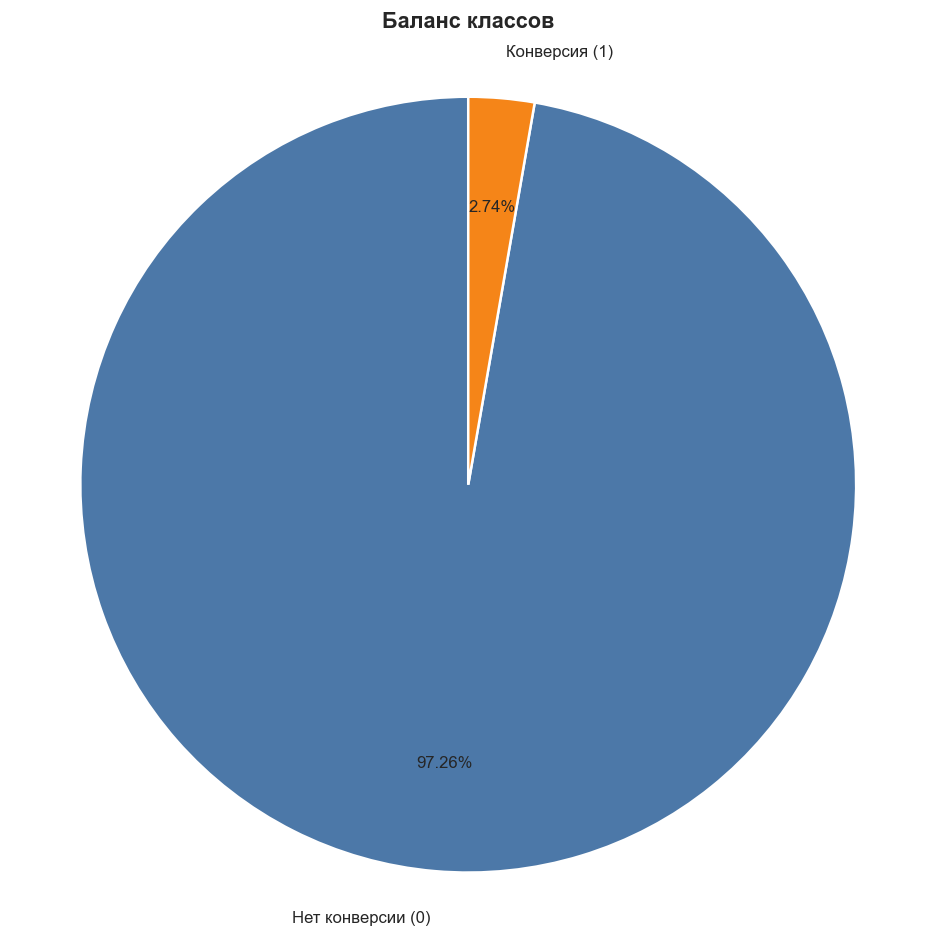

In [86]:
counts = df_final['is_target'].value_counts().sort_index()
labels = ['Нет конверсии (0)', 'Конверсия (1)']
colors = ['#4C78A8', '#F58518']

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    counts.values,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    labeldistance=1.12,
    pctdistance=0.72,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10}
)

plt.title('Баланс классов', fontsize=13, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

**Вывод по подготовке:**

- Всего сессий: ~1.86 млн, целевых — ~51 тыс., конверсия ≈ 2.74%.  
- Дисбаланс классов порядка 1:35, поэтому accuracy будет малоинформативен.  
- Для оценки модели используем ROC-AUC, которая меньше чувствительна к дисбалансу.

### Распределение `visit_number` и клиппинг хвоста

Проверим, насколько длинный хвост у количества визитов и как меняется конверсия при разных порогах.

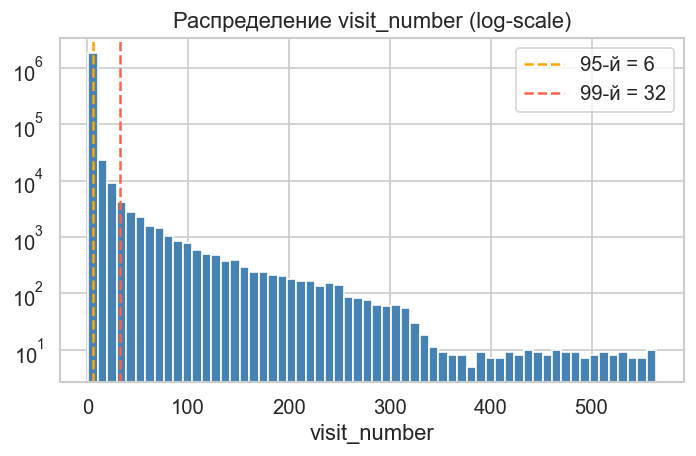

In [27]:
p95 = df_final['visit_number'].quantile(0.95)
p99 = df_final['visit_number'].quantile(0.99)

plt.figure(figsize=(6, 4))
plt.hist(
    df_final['visit_number'],
    bins=60,
    color='steelblue',
    edgecolor='white',
    lw=0.4
)
plt.yscale('log')

plt.axvline(p95, color='orange', linestyle='--', lw=1.5, label=f'95-й = {p95:.0f}')
plt.axvline(p99, color='tomato', linestyle='--', lw=1.5, label=f'99-й = {p99:.0f}')

plt.title('Распределение visit_number (log-scale)')
plt.xlabel('visit_number')
plt.legend()
plt.tight_layout()
plt.show()

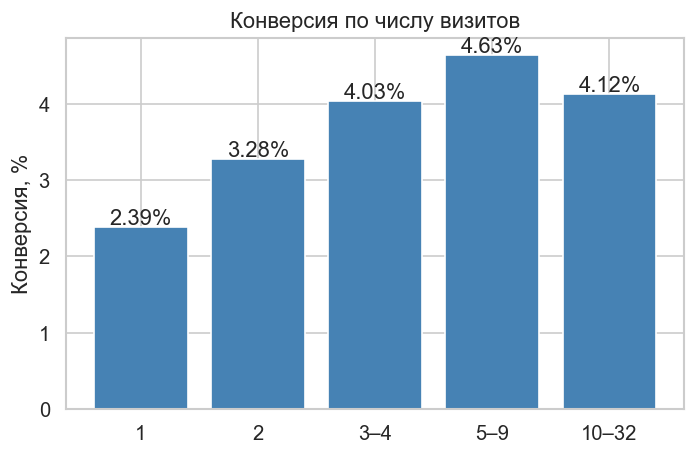

In [28]:
bins_ = [0, 1, 2, 4, 9, int(p99) + 1]
labels_ = ['1', '2', '3–4', '5–9', f'10–{int(p99)}']

df_tmp = df_final.copy()
df_tmp['vn_bucket'] = pd.cut(df_tmp['visit_number'], bins=bins_, labels=labels_)

conv_vn = df_tmp.groupby('vn_bucket', observed=True)['is_target'].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(conv_vn.index, conv_vn.values, color='steelblue', edgecolor='white')
plt.title('Конверсия по числу визитов')
plt.ylabel('Конверсия, %')

for i, v in enumerate(conv_vn.values):
    plt.text(i, v + 0.03, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

In [29]:
p95 = df_final['visit_number'].quantile(0.95)
above_95 = (df_final['visit_number'] > p95).mean() * 100
cr_above_95 = df_final[df_final['visit_number'] > p95]['is_target'].mean() * 100

print(f"95-й перцентиль: {p95:.0f}")
print(f"Доля сессий выше 95-го перцентиля: {above_95:.2f}%")
print(f"CR для > {p95:.0f} визитов: {cr_above_95:.2f}%")

p99 = df_final['visit_number'].quantile(0.99)
above_99 = (df_final['visit_number'] > p99).mean() * 100
cr_above_99 = df_final[df_final['visit_number'] > p99]['is_target'].mean() * 100

print(f"99-й перцентиль: {p99:.0f}")
print(f"Доля сессий выше 99-го перцентиля: {above_99:.2f}%")
print(f"CR для > {p99:.0f} визитов: {cr_above_99:.2f}%")

95-й перцентиль: 6
Доля сессий выше 95-го перцентиля: 4.55%
CR для > 6 визитов: 4.28%
99-й перцентиль: 32
Доля сессий выше 99-го перцентиля: 0.99%
CR для > 32 визитов: 4.09%


In [30]:
print(f"Макс. значение visit_number: {df_final['visit_number'].max()}")
print(f"Среднее значение: {df_final['visit_number'].mean():.2f}")
print(f"Медиана: {df_final['visit_number'].median():.0f}")
print(f"99-й перцентиль: {p99:.0f}")

Макс. значение visit_number: 564
Среднее значение: 2.71
Медиана: 1
99-й перцентиль: 32


Клиппинг по 99-му перцентилю (≈ 32 визита) позволяет отрезать редкий хвост, почти не задевая живых пользователей, но снимая очень длинные истории поведения.

### Источники трафика и конверсия

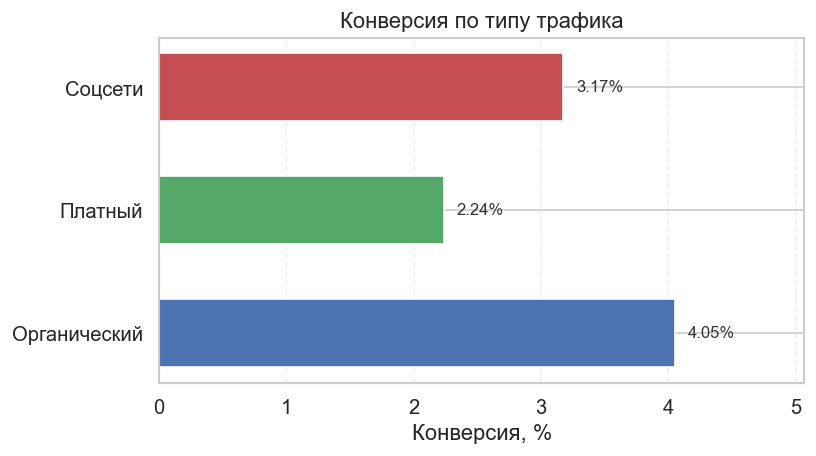

In [76]:
cr_traffic = {
    "Органический": df_final[df_final["is_organic"] == 1]["is_target"].mean() * 100,
    "Платный": df_final[df_final["is_paid"] == 1]["is_target"].mean() * 100,
    "Соцсети": df_final[df_final["is_social"] == 1]["is_target"].mean() * 100,
}

labels = list(cr_traffic.keys())
values = list(cr_traffic.values())

plt.figure(figsize=(7, 4))
bars = plt.barh(
    labels,
    values,
    color=["#4C72B0", "#55A868", "#C44E52"], 
    height=0.55
)

plt.xlabel("Конверсия, %")
plt.title("Конверсия по типу трафика")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for i, v in enumerate(values):
    plt.text(
        v + 0.1,
        i,
        f"{v:.2f}%",
        va="center",
        fontsize=10,
        color="#333333"
    )

plt.xlim(0, max(values) * 1.25)
plt.tight_layout()
plt.show()

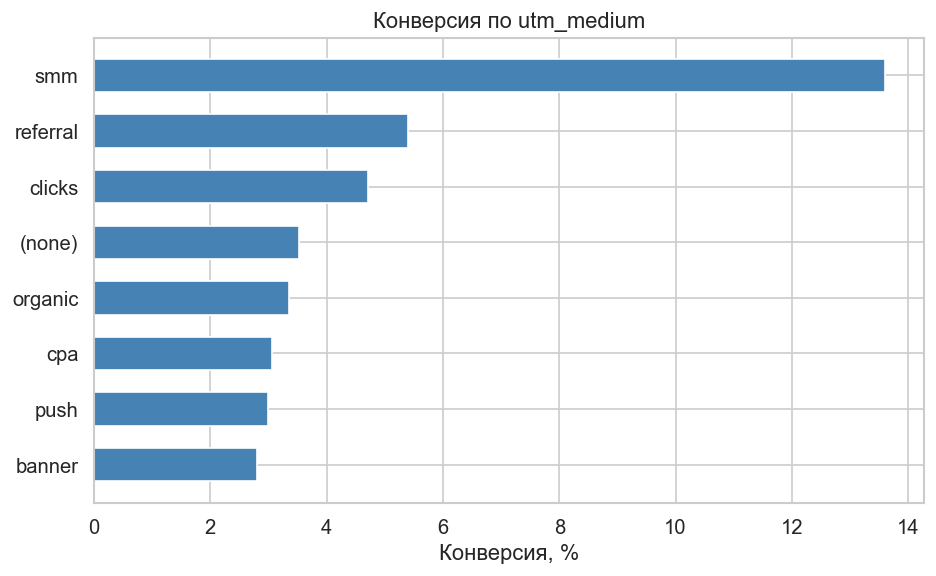

In [32]:
cr_medium = (
    df_final
    .groupby('utm_medium')['is_target']
    .agg(['mean', 'count'])
    .query('count >= 500')
    .nlargest(8, 'mean')
    .reset_index()
)

cr_medium['cr_pct'] = cr_medium['mean'] * 100

plt.figure(figsize=(8, 5))
plt.barh(cr_medium['utm_medium'], cr_medium['cr_pct'], color='steelblue', height=0.6)
plt.xlabel('Конверсия, %')
plt.title('Конверсия по utm_medium')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Временной анализ

Выделим признаки: час визита, день недели и месяц, чтобы отследить дневную и сезонную динамику спроса.

In [36]:
import numpy as np

# visit_date → datetime
df_final['visit_date'] = pd.to_datetime(df_final['visit_date'], errors='coerce')

if pd.api.types.is_datetime64_any_dtype(df_final['visit_time']):
    # если это уже datetime64[ns]
    df_final['visit_hour'] = df_final['visit_time'].dt.hour
else:
    df_final['visit_hour'] = df_final['visit_time'].apply(
        lambda x: x.hour if hasattr(x, 'hour') else np.nan
    )

# день недели и месяц из visit_date
df_final['visit_dayofweek'] = df_final['visit_date'].dt.dayofweek
df_final['visit_month'] = df_final['visit_date'].dt.month

day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

cr_hour = df_final.groupby('visit_hour')['is_target'].mean() * 100
cr_month = df_final.groupby('visit_month')['is_target'].mean() * 100

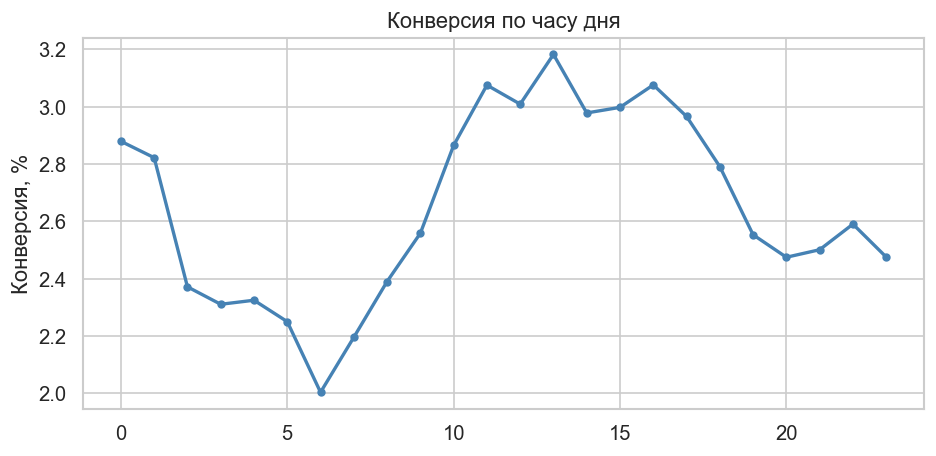

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(cr_hour.index, cr_hour.values, color='steelblue', marker='o', ms=4, lw=2)
plt.title('Конверсия по часу дня')
plt.ylabel('Конверсия, %')
plt.tight_layout()
plt.show()

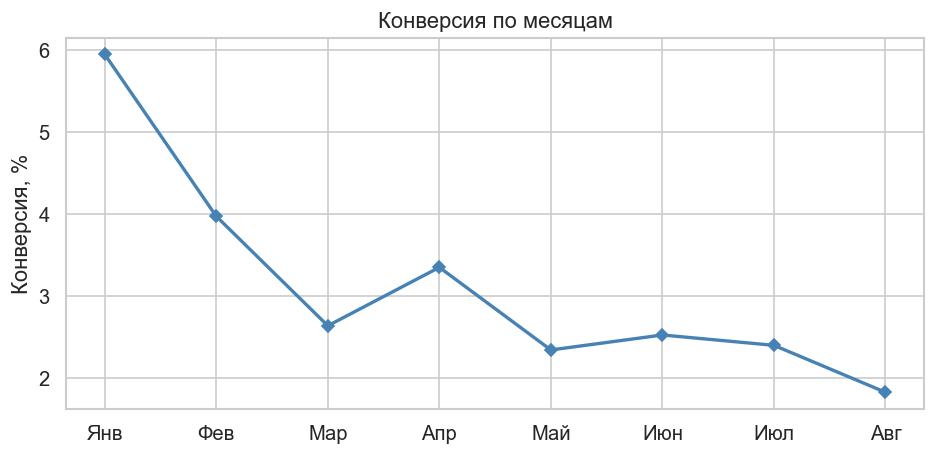

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(
    month_names[:len(cr_month)],
    cr_month.values,
    color='steelblue',
    marker='D',
    ms=5,
    lw=2
)
plt.title('Конверсия по месяцам')
plt.ylabel('Конверсия, %')
plt.tight_layout()
plt.show()

### Устройства и география

In [40]:
cr_dev = (
    df_final
    .groupby('device_category')['is_target']
    .mean() * 100
).sort_values(ascending=False)

cr_os = (
    df_final
    .groupby('device_os')['is_target']
    .agg(['mean', 'count'])
    .query('count >= 500')
    .nlargest(7, 'mean')
    .reset_index()
)
cr_os['cr_pct'] = cr_os['mean'] * 100

top_cities = (
    df_final
    .groupby('geo_city')['is_target']
    .agg(['mean', 'count'])
    .query('count >= 1000')
    .nlargest(10, 'count')
    .reset_index()
)
top_cities['cr_pct'] = top_cities['mean'] * 100

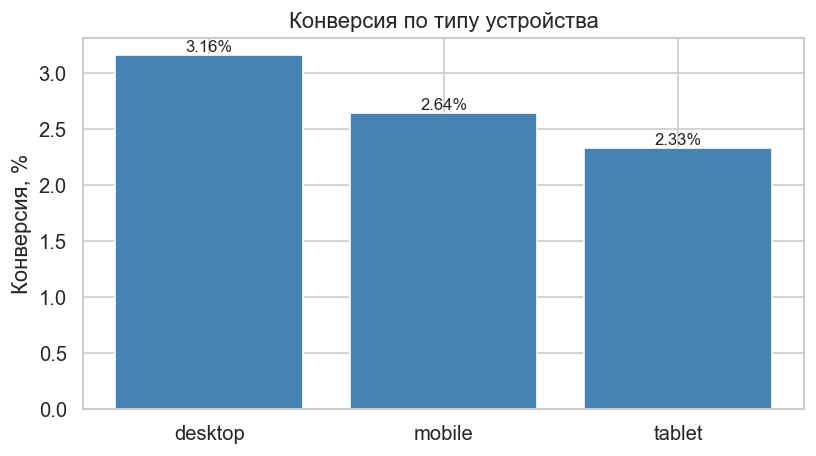

In [41]:
plt.figure(figsize=(7, 4))
plt.bar(cr_dev.index, cr_dev.values, color='steelblue', edgecolor='white')
plt.title('Конверсия по типу устройства')
plt.ylabel('Конверсия, %')

for i, v in enumerate(cr_dev.values):
    plt.text(i, v + 0.03, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

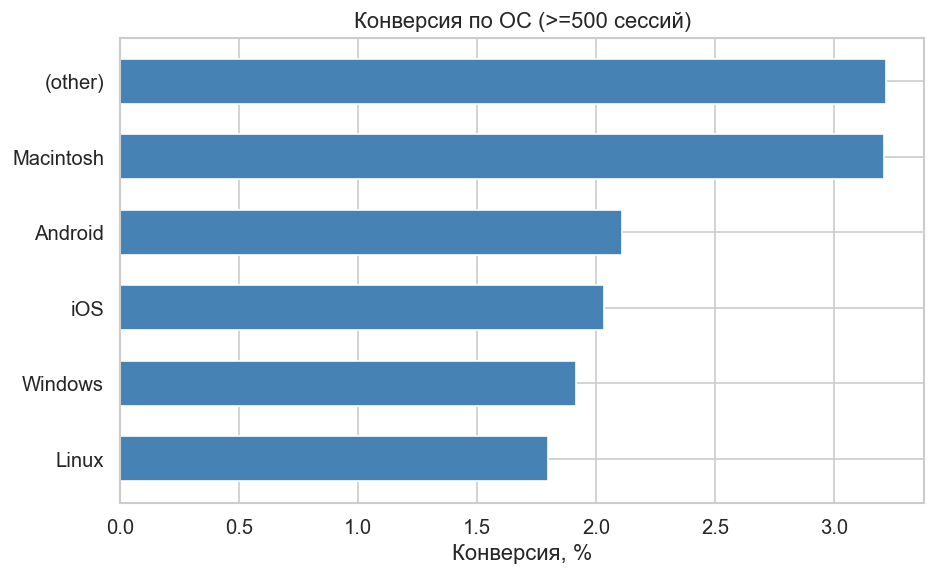

In [42]:
plt.figure(figsize=(8, 5))
plt.barh(cr_os['device_os'], cr_os['cr_pct'], color='steelblue', height=0.6)
plt.title('Конверсия по ОС (>=500 сессий)')
plt.xlabel('Конверсия, %')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Матрицы корреляций (PhiK)

Проверим взаимосвязи между признаками и таргетом, а также между самими признаками, чтобы оценить риск мультиколлинеарности.

In [50]:

base_features = [
    'is_target',
    'is_paid',
    'is_organic',
    'is_social',
    'visit_number',
    'device_category',
    'device_os',
    'device_browser'
]

def top_n_or_other(series, n=10):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), other='other')

df_final['city_bucket'] = top_n_or_other(df_final['geo_city'])
df_final['source_bucket'] = top_n_or_other(df_final['utm_source'])
df_final['medium_bucket'] = top_n_or_other(df_final['utm_medium'])

ext_features = [
    'is_target',
    'is_paid',
    'visit_number',
    'visit_month',
    'visit_dayofweek',
    'visit_hour',
    'device_category',
    'source_bucket',
    'city_bucket',
    'medium_bucket'
]

SAMPLE = 100_000

print("PhiK на базовых признаках")
phik_base = df_final[base_features].sample(SAMPLE, random_state=42).phik_matrix()

print("PhiK на расширенных признаках")
phik_ext = df_final[ext_features].sample(SAMPLE, random_state=42).phik_matrix()

PhiK на базовых признаках
interval columns not set, guessing: ['is_target', 'is_paid', 'is_organic', 'is_social', 'visit_number']
PhiK на расширенных признаках
interval columns not set, guessing: ['is_target', 'is_paid', 'visit_number', 'visit_month', 'visit_dayofweek', 'visit_hour']


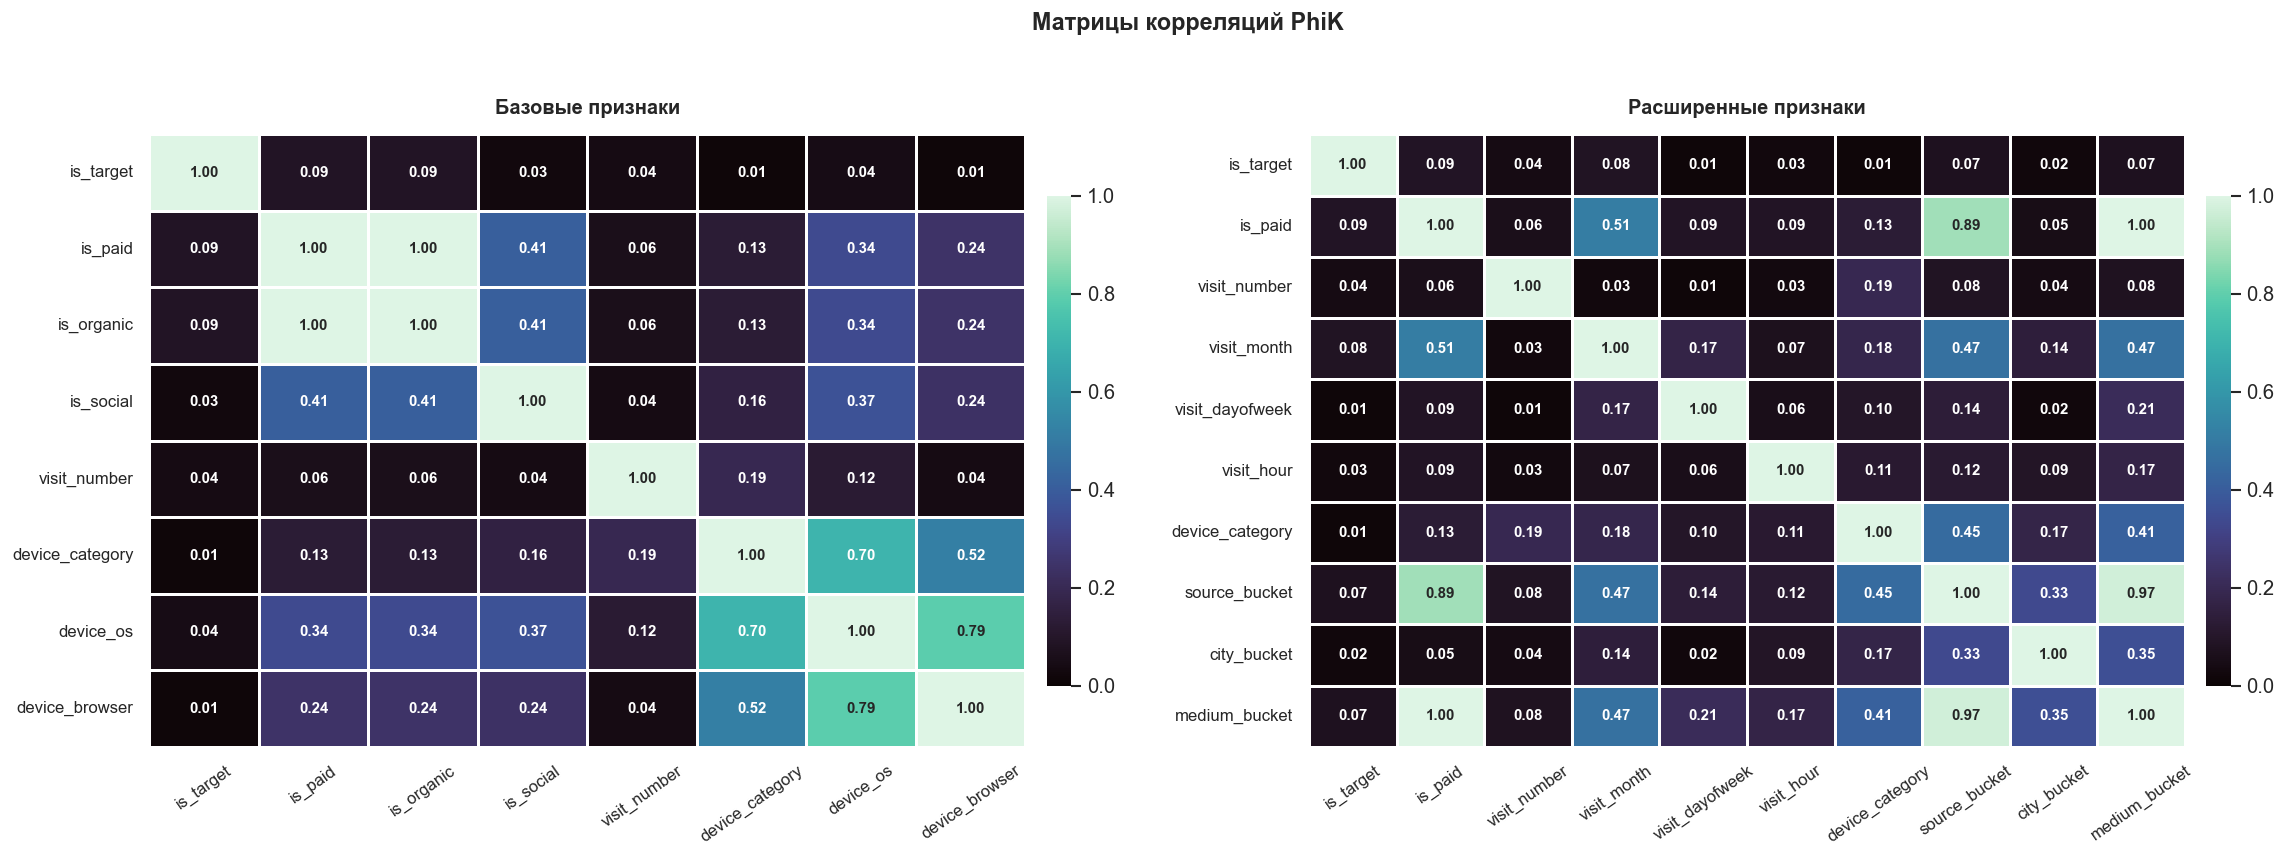


Рейтинг признаков по PhiK с is_target

Базовые признаки
is_target          1.000000
is_paid            0.088075
is_organic         0.088075
device_os          0.043432
visit_number       0.040983
is_social          0.025677
device_browser     0.013899
device_category    0.012069

Расширенные признаки
is_target          1.000000
is_paid            0.088075
visit_month        0.082044
medium_bucket      0.073600
source_bucket      0.073380
visit_number       0.040983
visit_hour         0.026544
city_bucket        0.022876
visit_dayofweek    0.014133
device_category    0.012069


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Матрицы корреляций PhiK', fontsize=14, fontweight='bold', y=1.02)

cmap = sns.color_palette("mako", as_cmap=True)

for ax, matrix, title in zip(
    axes,
    [phik_base, phik_ext],
    ['Базовые признаки', 'Расширенные признаки']
):
    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        vmin=0,
        vmax=1,
        linewidths=0.8,
        linecolor='#FFFFFF',
        cbar_kws={'shrink': 0.8, 'pad': 0.02},
        annot_kws={'size': 9, 'weight': 'bold'}
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=35, labelsize=10)
    ax.tick_params(axis='y', rotation=0, labelsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

print("\nРейтинг признаков по PhiK с is_target")

print("\nБазовые признаки")
print(phik_base['is_target'].sort_values(ascending=False).to_string())

print("\nРасширенные признаки")
print(phik_ext['is_target'].sort_values(ascending=False).to_string())

По PhiK наиболее информативны:
- `is_paid` / `is_organic`;
- `visit_month`;
- агрегированные источники (`source_bucket` и `medium_bucket`);
- а также `visit_number` и `visit_hour`.

При этом сильной мультиколлинеарности между числовыми признаками не наблюдается.

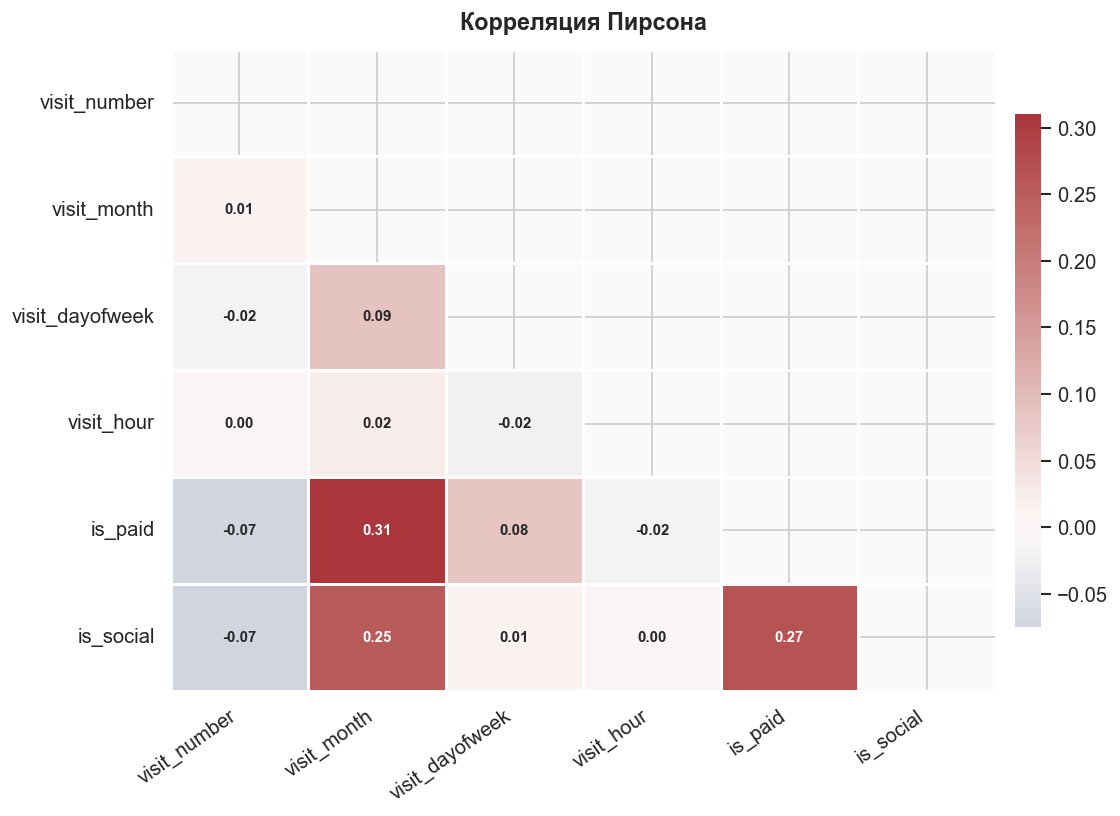

In [83]:
corr_pearson = X.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='vlag',          
    center=0,
    linewidths=0.8,
    linecolor='#FFFFFF',
    cbar_kws={'shrink': 0.8, 'pad': 0.02},
    annot_kws={'size': 9, 'weight': 'bold'}
)

plt.title('Корреляция Пирсона', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.gca().set_facecolor('#FAFAFA')
plt.tight_layout()
plt.show()

## 3. ML-модель

Дальше построим две модели:
1. Логистическая регрессия (линейная, для интерпретации).
2. Случайный лес (нелинейная модель, как основной кандидат).

In [52]:
df_model = df_final.copy()

In [53]:
def collapse_rare(series, n=10):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), other='other')

df_model['source'] = collapse_rare(df_model['utm_source'])
df_model['city'] = collapse_rare(df_model['geo_city'])

In [54]:
features = [
    'visit_number',
    'visit_month',
    'visit_dayofweek',
    'visit_hour',
    'is_paid',
    'is_social',
    'device_category',
    'source',
    'city'
]

X = df_model[features]
y = df_model['is_target']

### Проверка мультиколлинеарности (VIF и корреляция)

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = X.select_dtypes(include=np.number).dropna()

vif = pd.DataFrame()
vif['feature'] = X_num.columns
vif['VIF'] = [variance_inflation_factor(X_num.values, i)
              for i in range(X_num.shape[1])]

vif.sort_values('VIF', ascending=False)

,feature,VIF
1,visit_month,9.463349
3,visit_hour,4.849726
4,is_paid,4.179058
2,visit_dayofweek,2.887672
5,is_social,1.872491
0,visit_number,1.062375


In [56]:
corr_spearman = X.select_dtypes(include=np.number).corr(method='spearman')
print(corr_spearman)

                 visit_number  visit_month  visit_dayofweek  visit_hour   is_paid  is_social
visit_number         1.000000    -0.069171        -0.000973    0.020662 -0.153096  -0.201337
visit_month         -0.069171     1.000000         0.075867    0.022671  0.287764   0.259988
visit_dayofweek     -0.000973     0.075867         1.000000   -0.018215  0.084566   0.013705
visit_hour           0.020662     0.022671        -0.018215    1.000000 -0.009983  -0.003350
is_paid             -0.153096     0.287764         0.084566   -0.009983  1.000000   0.266129
is_social           -0.201337     0.259988         0.013705   -0.003350  0.266129   1.000000


VIF и матрицы корреляций показывают, что критической мультиколлинеарности нет, все признаки можно оставить в модели.

### Трейн / тест и клиппинг `visit_number`

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clipin = int(X_train['visit_number'].quantile(0.99))

X_train = X_train.copy()
X_test = X_test.copy()

X_train['visit_number'] = X_train['visit_number'].clip(upper=clipin)
X_test['visit_number'] = X_test['visit_number'].clip(upper=clipin)

print(f'Порог клиппинга (по трейну): {clipin}')
print(
    f'Train: {X_train.shape[0]:>10,} строк, конверсия = {y_train.mean():.4f}'
)
print(
    f'Test : {X_test.shape[0]:>10,} строк, конверсия = {y_test.mean():.4f}'
)
print(f'Признаков в модели: {X_train.shape[1]}')

Порог клиппинга (по трейну): 32
Train:  1,488,033 строк, конверсия = 0.0274
Test :    372,009 строк, конверсия = 0.0274
Признаков в модели: 9


### Логистическая регрессия

Признаков после кодирования: 39


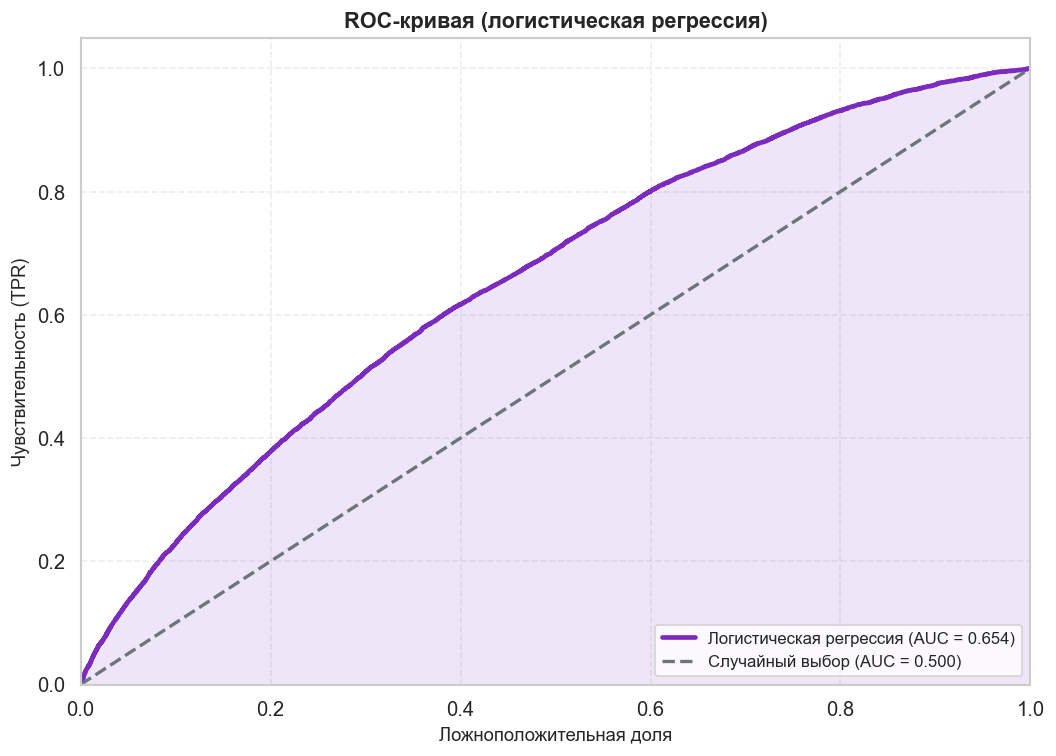

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

categorical_cols = [
    'visit_month',
    'visit_dayofweek',
    'device_category',
    'source',
    'city'
]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)
X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f'Признаков после кодирования: {X_train_scaled.shape[1]}')

logreg_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
logreg_model.fit(X_train_scaled, y_train)

y_pred_proba_lr = logreg_model.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

plt.figure(figsize=(9, 6.5))

plt.plot(
    fpr_lr,
    tpr_lr,
    color='#7B2CBF',  # фиолетовый
    lw=2.8,
    label=f'Логистическая регрессия (AUC = {roc_auc_lr:.3f})'
)

plt.plot(
    [0, 1], [0, 1],
    color='#6C757D',  # нейтральный серый
    lw=2,
    linestyle='--',
    label='Случайный выбор (AUC = 0.500)'
)

plt.fill_between(
    fpr_lr,
    tpr_lr,
    alpha=0.12,
    color='#7B2CBF'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ложноположительная доля', fontsize=11)
plt.ylabel('Чувствительность (TPR)', fontsize=11)
plt.title('ROC-кривая (логистическая регрессия)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### Случайный лес

Обучение случайного леса...


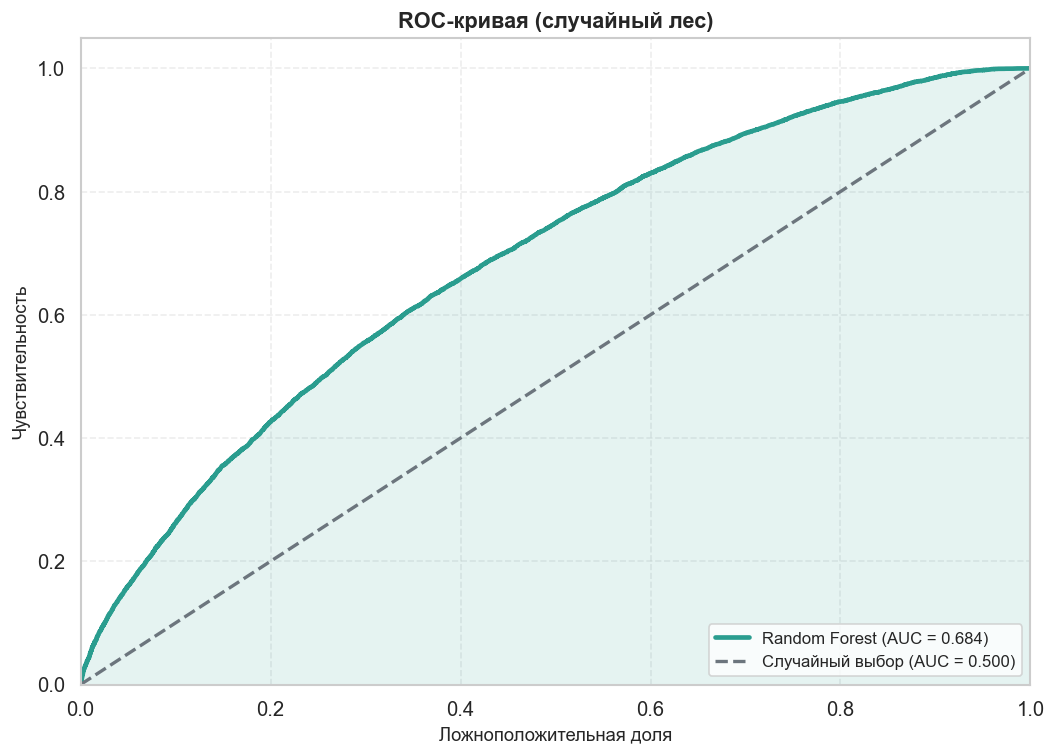

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [
    'visit_month',
    'visit_dayofweek',
    'device_category',
    'source',
    'city'
]

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

X_train_rf[categorical_cols] = encoder.fit_transform(
    X_train[categorical_cols].astype(str)
)
X_test_rf[categorical_cols] = encoder.transform(
    X_test[categorical_cols].astype(str)
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Обучение случайного леса...')
rf_model.fit(X_train_rf, y_train)

y_pred_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

plt.figure(figsize=(9, 6.5))

plt.plot(
    fpr_rf,
    tpr_rf,
    color='#2A9D8F',   
    lw=2.8,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

plt.plot(
    [0, 1], [0, 1],
    color='#6C757D',   
    lw=2,
    linestyle='--',
    label='Случайный выбор (AUC = 0.500)'
)

plt.fill_between(
    fpr_rf,
    tpr_rf,
    alpha=0.12,
    color='#2A9D8F'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ложноположительная доля', fontsize=11)
plt.ylabel('Чувствительность', fontsize=11)
plt.title('ROC-кривая (случайный лес)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### CatBoost

Обучение CatBoost...
0:	total: 617ms	remaining: 5m 7s
100:	total: 45.3s	remaining: 2m 59s
200:	total: 1m 31s	remaining: 2m 16s
300:	total: 2m 13s	remaining: 1m 28s
400:	total: 2m 59s	remaining: 44.4s
499:	total: 3m 45s	remaining: 0us


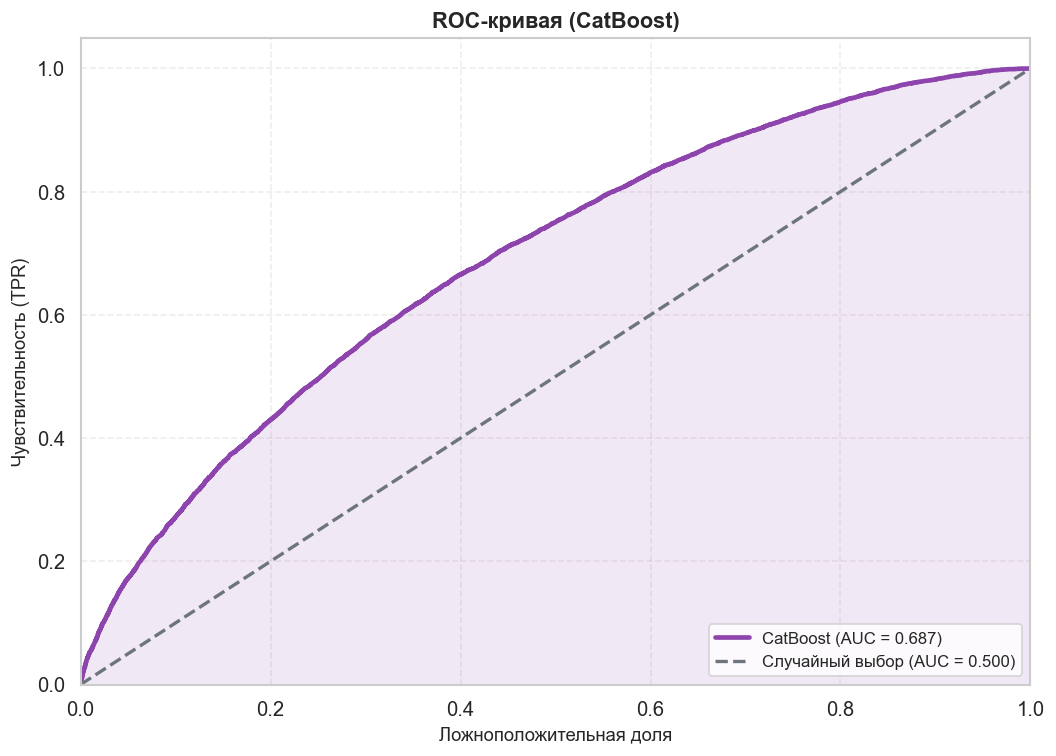

Итоговый ROC-AUC (CatBoost): 0.6874


In [88]:
from catboost import CatBoostClassifier, Pool

cat_features = [
    'visit_month',
    'visit_dayofweek',
    'device_category',
    'source',
    'city'
]

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

train_pool = Pool(X_train_cb, y_train, cat_features=cat_features)
test_pool = Pool(X_test_cb, y_test, cat_features=cat_features)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    class_weights=[1, 3]
)

print('Обучение CatBoost...')
cat_model.fit(train_pool)

y_pred_proba_cb = cat_model.predict_proba(test_pool)[:, 1]

fpr_cb, tpr_cb, thresholds_cb = roc_curve(y_test, y_pred_proba_cb)
roc_auc_cb = roc_auc_score(y_test, y_pred_proba_cb)

plt.figure(figsize=(9, 6.5))
plt.plot(
    fpr_cb,
    tpr_cb,
    color='#8E44AD',
    lw=2.8,
    label=f'CatBoost (AUC = {roc_auc_cb:.3f})'
)
plt.plot(
    [0, 1], [0, 1],
    color='#6C757D',
    lw=2,
    linestyle='--',
    label='Случайный выбор (AUC = 0.500)'
)
plt.fill_between(fpr_cb, tpr_cb, alpha=0.12, color='#8E44AD')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ложноположительная доля', fontsize=11)
plt.ylabel('Чувствительность (TPR)', fontsize=11)
plt.title('ROC-кривая (CatBoost)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

print(f'Итоговый ROC-AUC (CatBoost): {roc_auc_cb:.4f}')

### Важность признаков

Посмотрим, какие признаки наиболее сильно влияют на предсказания обеих моделей.

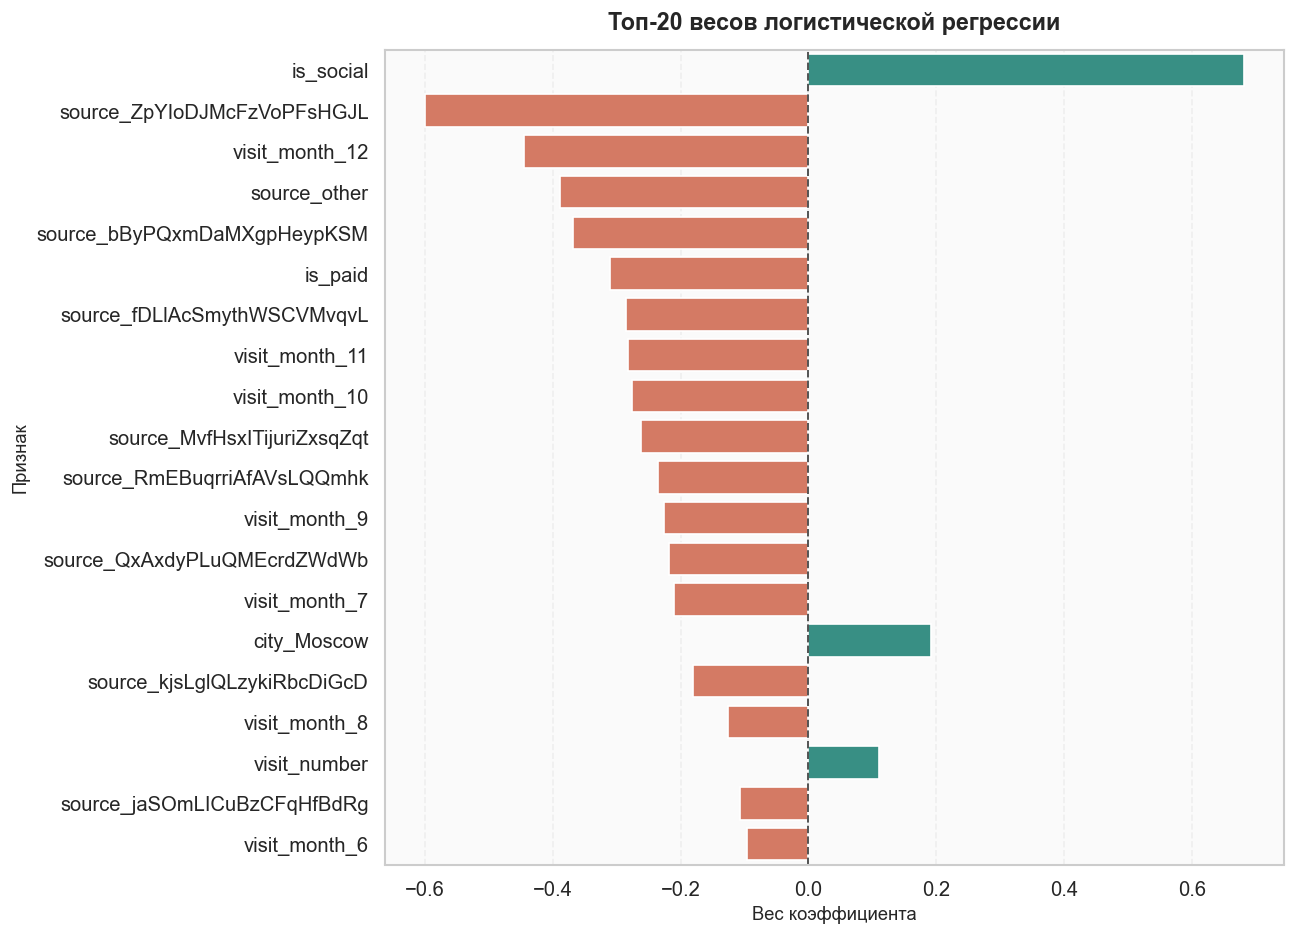

In [82]:
# Для логистической регрессии (по абсолютной величине коэффициентов)
feature_names_lr = X_train_encoded.columns
coefficients = logreg_model.coef_[0]

lr_importance = pd.DataFrame({
    'feature': feature_names_lr,
    'coef': coefficients,
    'abs_coef': np.abs(coefficients)
}).sort_values(by='abs_coef', ascending=False)

top_lr = lr_importance.head(20).copy()
top_lr['color'] = top_lr['coef'].apply(
    lambda x: '#2A9D8F' if x > 0 else '#E76F51'
)

plt.figure(figsize=(11, 8))
bars = sns.barplot(
    x='coef',
    y='feature',
    data=top_lr,
    palette=top_lr['color'].tolist(),
    hue='feature',
    legend=False
)

plt.axvline(x=0, color='#2F2F2F', linestyle='--', alpha=0.8, linewidth=1.2)
plt.title('Топ-20 весов логистической регрессии', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Вес коэффициента', fontsize=11)
plt.ylabel('Признак', fontsize=11)
plt.grid(True, axis='x', linestyle='--', alpha=0.25)
plt.gca().set_facecolor('#FAFAFA')
plt.tight_layout()
plt.show()

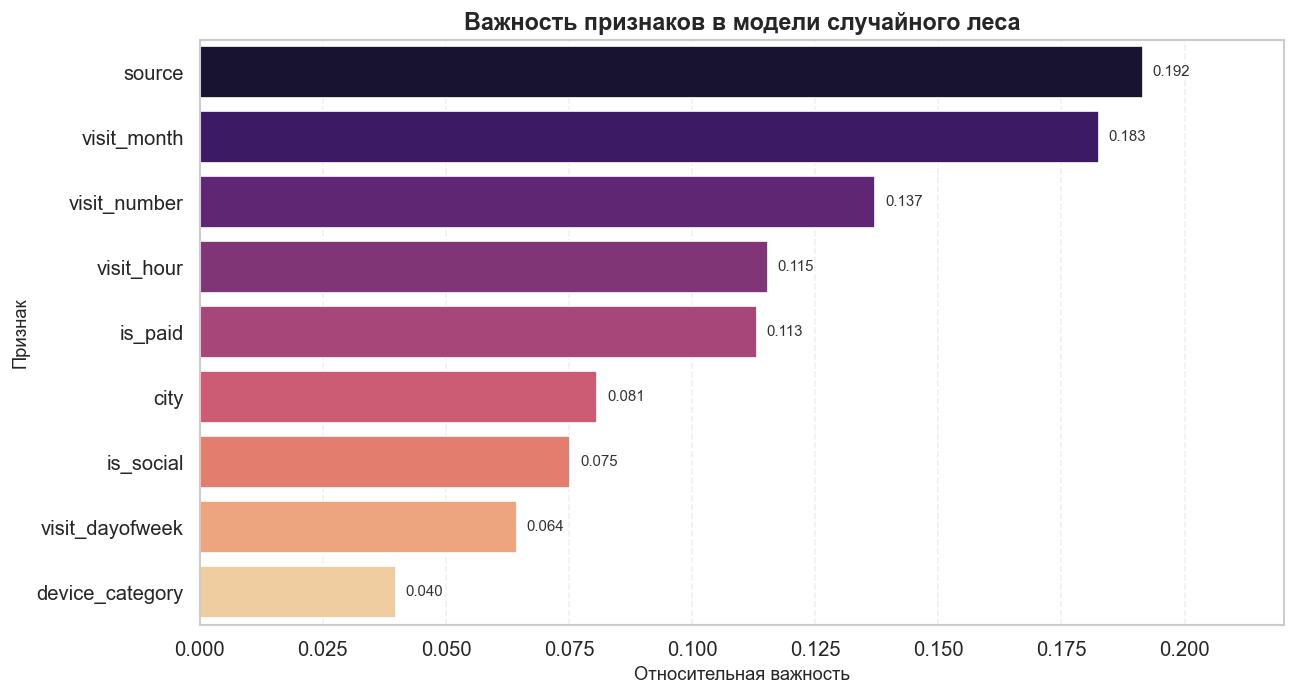

In [85]:
# Для случайного леса (feature_importances_)
importances_rf = rf_model.feature_importances_
feature_names_rf = X_train_rf.columns

rf_importance = pd.DataFrame({
    'feature': feature_names_rf,
    'importance': importances_rf
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(11, 6))
bars = sns.barplot(
    x='importance',
    y='feature',
    data=rf_importance,
    palette='magma',
    hue='feature',
    legend=False
)

plt.title('Важность признаков в модели случайного леса', fontsize=14, fontweight='bold')
plt.xlabel('Относительная важность', fontsize=11)
plt.ylabel('Признак', fontsize=11)
plt.grid(True, axis='x', linestyle='--', alpha=0.3)

for bar in bars.patches:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.3f}',
        va='center',
        fontsize=9,
        color='#333333'
    )

plt.xlim(0, rf_importance['importance'].max() * 1.15)
plt.tight_layout()
plt.show()

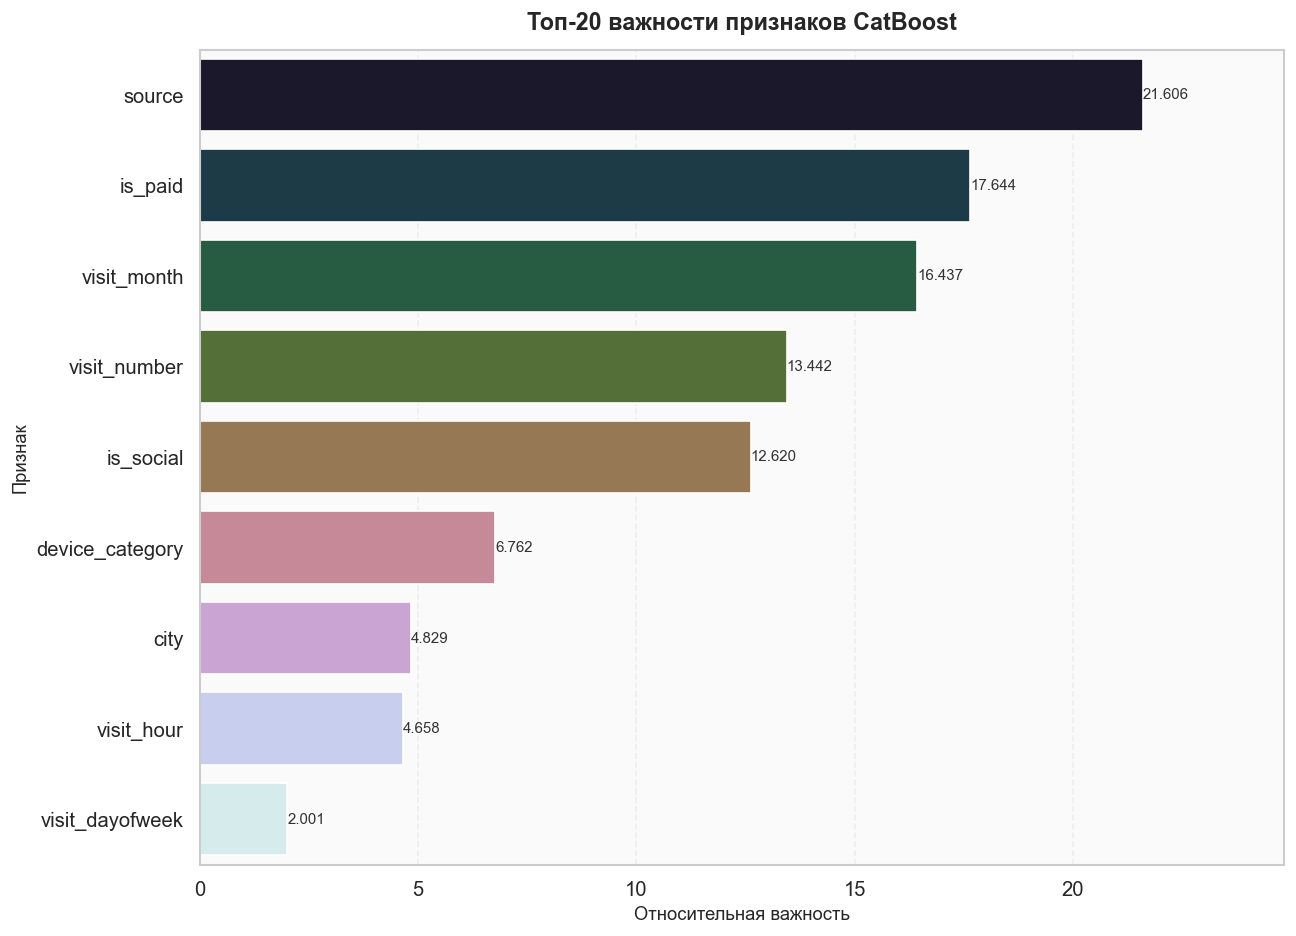

In [89]:
# Важность признаков для CatBoost
cb_importance = pd.DataFrame({
    'feature': X_train_cb.columns,
    'importance': cat_model.get_feature_importance(train_pool)
}).sort_values(by='importance', ascending=False)

top_cb = cb_importance.head(20)

plt.figure(figsize=(11, 8))
bars = sns.barplot(
    x='importance',
    y='feature',
    data=top_cb,
    palette='cubehelix',
    hue='feature',
    legend=False
)

plt.title('Топ-20 важности признаков CatBoost', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Относительная важность', fontsize=11)
plt.ylabel('Признак', fontsize=11)
plt.grid(True, axis='x', linestyle='--', alpha=0.25)
plt.gca().set_facecolor('#FAFAFA')

for bar in bars.patches:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.3f}',
        va='center',
        fontsize=9,
        color='#333333'
    )

plt.xlim(0, top_cb['importance'].max() * 1.15)
plt.tight_layout()
plt.show()

## Вывод по моделям

- Логистическая регрессия показала ROC-AUC около 0.654 и служит хорошей базовой моделью.
- Случайный лес улучшил качество до ROC-AUC около 0.684 и лучше улавливает нелинейные зависимости.
- CatBoost продемонстрировал наилучший результат с ROC-AUC около 0.687 и чуть-чуть превосходит случайный лес по качеству.

По важности признаков все модели опираются на схожие ключевые факторы: тип и источник трафика, месяц визита и признаки активности. Логистическая регрессия остаётся наиболее удобной для интерпретации знака влияния признаков, случайный лес и CatBoost дают более высокое качество, при этом CatBoost показывает немного лучший ROC-AUC и может быть выбран в качестве финальной модели.

## 4. Упаковка модели

Соберем финальный пайплайн, который:
- принимает данные визита с теми же признаками, что и в обучении;
- клиппит `visit_number` по выбранному порогу;
- кодирует категориальные признаки;
- выдает вероятность и/или класс (0/1).

In [90]:
import joblib
from catboost import CatBoostClassifier, Pool

categorical_cols_final = [
    'visit_month',
    'visit_dayofweek',
    'device_category',
    'source',
    'city'
]

X_full = X.copy()
X_full['visit_number'] = X_full['visit_number'].clip(upper=clipin)

for col in categorical_cols_final:
    X_full[col] = X_full[col].astype(str)

cat_model_final = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    class_weights=[1, 3]
)

train_pool_full = Pool(
    X_full,
    y,
    cat_features=categorical_cols_final
)

cat_model_final.fit(train_pool_full)
print('Финальная CatBoost-модель обучена')

model_filename = 'model.pkl'
joblib.dump(
    {
        'model': cat_model_final,
        'clip_threshold': clipin,
        'categorical_cols': categorical_cols_final
    },
    model_filename
)

print(f'Артефакт сохранен: {model_filename}')

0:	total: 629ms	remaining: 5m 14s
100:	total: 1m 12s	remaining: 4m 45s
200:	total: 2m 29s	remaining: 3m 41s
300:	total: 3m 44s	remaining: 2m 28s
400:	total: 5m 30s	remaining: 1m 21s
499:	total: 7m 21s	remaining: 0us
Финальная CatBoost-модель обучена
Артефакт сохранен: model.pkl


# Тест

In [69]:
import pandas as pd
from pathlib import Path

sample = pd.DataFrame({
    "visit_number": [1, 3, 5, 2, 10],
    "visit_month": [1, 3, 5, 7, 12],
    "visit_dayofweek": [0, 2, 4, 5, 6],
    "visit_hour": [10, 14, 20, 23, 3],
    "is_paid": [0, 1, 0, 1, 1],
    "is_social": [0, 0, 1, 1, 0],
    "city": ["Moscow", "Moscow", "SPb", "Kazan", "Novosibirsk"],
    "source": ["yandex", "google", "direct", "social", "email"],
    "device_category": ["desktop", "mobile", "mobile", "tablet", "desktop"],
})

Path("data").mkdir(exist_ok=True)
sample.to_csv("data/sample_infer.csv", index=False)
sample

,visit_number,visit_month,visit_dayofweek,visit_hour,is_paid,is_social,city,source,device_category
0,1,1,0,10,0,0,Moscow,yandex,desktop
1,3,3,2,14,1,0,Moscow,google,mobile
2,5,5,4,20,0,1,SPb,direct,mobile
3,2,7,5,23,1,1,Kazan,social,tablet
4,10,12,6,3,1,0,Novosibirsk,email,desktop


In [98]:
%%bash
python infer.py

Saved predictions to /Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/predictions.csv


In [99]:
preds = pd.read_csv("data/predictions.csv")
preds.head()

,visit_number,visit_month,visit_dayofweek,visit_hour,is_paid,is_social,city,source,device_category,proba
0,1,1,0,10,0,0,Moscow,yandex,desktop,0.197420
1,3,3,2,14,1,0,Moscow,google,mobile,0.087142
2,5,5,4,20,0,1,SPb,direct,mobile,0.081860
3,2,7,5,23,1,1,Kazan,social,tablet,0.088706
4,10,12,6,3,1,0,Novosibirsk,email,desktop,0.027991
